In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


Device: cuda


In [30]:
df = pd.read_csv("/kaggle/input/datasets/arnav1909/imu-fsr-dataset/dataset_with_fsr (1).csv")

FEATURES = [
    "accel_x",
    "accel_y",
    "accel_z",
    "gyro_alpha",
    "gyro_beta",
    "gyro_gamma"
]

LABEL = "label"

df = df[FEATURES + [LABEL]].dropna().reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nLabels:")
print(df[LABEL].value_counts())


Dataset shape: (3569, 7)

Labels:
label
Fidgeting    930
Idle         920
Writing      886
Gripping     833
Name: count, dtype: int64


In [31]:
FS = 30.0

CUTOFF_HZ = 10.0
FILTER_ORDER = 4

WINDOW = 30       # ~1 second at 30 Hz
STRIDE = 15       # 50% overlap

SPLIT_RATIO = 0.80

# Behaviour classes that can generate feedback
TRIGGER_CLASSES = {
    "Fidgeting",
    "Idle"
}

print("Sampling rate:", FS, "Hz")
print("Window:", WINDOW, "samples")
print("Stride:", STRIDE, "samples")


Sampling rate: 30.0 Hz
Window: 30 samples
Stride: 15 samples


In [32]:
df["block"] = (
    df[LABEL]
    .ne(df[LABEL].shift())
    .cumsum()
)

b, a = butter(
    FILTER_ORDER,
    CUTOFF_HZ / (FS / 2),
    btype="low"
)

blocks = []

for _, group in df.groupby("block"):

    label = group[LABEL].iloc[0]

    raw = group[FEATURES].to_numpy(
        dtype=float
    )

    filtered = filtfilt(
        b,
        a,
        raw,
        axis=0
    )

    blocks.append({
        "label": label,
        "raw": raw,
        "filtered": filtered
    })

print("Behaviour blocks:")

for block in blocks:
    print(
        block["label"],
        len(block["raw"])
    )


Behaviour blocks:
Idle 920
Fidgeting 930
Writing 886
Gripping 833


In [33]:
def make_windows(data, window, stride):

    return np.array([
        data[i:i + window]
        for i in range(
            0,
            len(data) - window + 1,
            stride
        )
    ])


train_X = []
train_y = []

test_X = []
test_y = []

test_stream_chunks = []
test_stream_labels = []

for block in blocks:

    data = block["filtered"]
    label = block["label"]

    split = int(
        len(data) * SPLIT_RATIO
    )

    train_data = data[:split]

    # Leave one complete window as a gap
    # between train and test
    test_data = data[
        split + WINDOW:
    ]

    train_windows = make_windows(
        train_data,
        WINDOW,
        STRIDE
    )

    test_windows = make_windows(
        test_data,
        WINDOW,
        STRIDE
    )

    if len(train_windows):

        train_X.append(train_windows)
        train_y += [
            label
        ] * len(train_windows)

    if len(test_windows):

        test_X.append(test_windows)
        test_y += [
            label
        ] * len(test_windows)

    # Keep raw test portion for simulation
    if len(test_data):

        test_stream_chunks.append(
            test_data
        )

        test_stream_labels += [
            label
        ] * len(test_data)


train_X = np.concatenate(train_X)
test_X = np.concatenate(test_X)

train_y = np.array(train_y)
test_y = np.array(test_y)

print("Train:", train_X.shape)
print("Test :", test_X.shape)

print("\nTrain labels:")
print(pd.Series(train_y).value_counts())

print("\nTest labels:")
print(pd.Series(test_y).value_counts())


Train: (185, 30, 6)
Test : (34, 30, 6)

Train labels:
Idle         48
Fidgeting    48
Writing      46
Gripping     43
Name: count, dtype: int64

Test labels:
Idle         9
Fidgeting    9
Writing      8
Gripping     8
Name: count, dtype: int64


In [34]:
scaler = StandardScaler()

scaler.fit(
    train_X.reshape(
        -1,
        len(FEATURES)
    )
)


def normalize(X):

    shape = X.shape

    return scaler.transform(
        X.reshape(
            -1,
            len(FEATURES)
        )
    ).reshape(shape)


train_X = normalize(train_X)
test_X = normalize(test_X)


classes = sorted(
    np.unique(train_y)
)

label_to_id = {
    label: i
    for i, label in enumerate(classes)
}

id_to_label = {
    i: label
    for label, i in label_to_id.items()
}

train_y_id = np.array([
    label_to_id[x]
    for x in train_y
])

test_y_id = np.array([
    label_to_id[x]
    for x in test_y
])

print("Classes:", classes)
print("Mapping:", label_to_id)


Classes: [np.str_('Fidgeting'), np.str_('Gripping'), np.str_('Idle'), np.str_('Writing')]
Mapping: {np.str_('Fidgeting'): 0, np.str_('Gripping'): 1, np.str_('Idle'): 2, np.str_('Writing'): 3}


In [35]:
class WindowDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        ).permute(0, 2, 1)

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):

        return (
            self.X[index],
            self.y[index]
        )


train_dataset = WindowDataset(
    train_X,
    train_y_id
)

test_dataset = WindowDataset(
    test_X,
    test_y_id
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

print("Training windows:", len(train_dataset))
print("Testing windows :", len(test_dataset))


Training windows: 185
Testing windows : 34


In [36]:
class CausalConv1d(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation
    ):

        super().__init__()

        self.padding = (
            kernel_size - 1
        ) * dilation

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=self.padding,
            dilation=dilation
        )

    def forward(self, x):

        y = self.conv(x)

        if self.padding > 0:

            y = y[
                :,
                :,
                :-self.padding
            ]

        return y


class TCNBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        dilation,
        dropout=0.2
    ):

        super().__init__()

        self.net = nn.Sequential(

            CausalConv1d(
                in_channels,
                out_channels,
                3,
                dilation
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            CausalConv1d(
                out_channels,
                out_channels,
                3,
                dilation
            ),

            nn.ReLU(),

            nn.Dropout(dropout)
        )

        self.skip = (
            nn.Conv1d(
                in_channels,
                out_channels,
                1
            )
            if in_channels != out_channels
            else nn.Identity()
        )

        self.relu = nn.ReLU()


    def forward(self, x):

        return self.relu(
            self.net(x) + self.skip(x)
        )


class TCN(nn.Module):

    def __init__(
        self,
        input_channels,
        num_classes
    ):

        super().__init__()

        self.tcn = nn.Sequential(

            TCNBlock(
                input_channels,
                16,
                dilation=1
            ),

            TCNBlock(
                16,
                16,
                dilation=2
            ),

            TCNBlock(
                16,
                16,
                dilation=4
            )
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(
            16,
            num_classes
        )


    def forward(self, x):

        x = self.tcn(x)

        x = self.pool(x)

        x = x.squeeze(-1)

        return self.fc(x)


model = TCN(
    input_channels=6,
    num_classes=len(classes)
).to(device)

print(model)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)


TCN(
  (tcn): Sequential(
    (0): TCNBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(6, 16, kernel_size=(3,), stride=(1,), padding=(2,))
        )
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): CausalConv1d(
          (conv): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(2,))
        )
        (4): ReLU()
        (5): Dropout(p=0.2, inplace=False)
      )
      (skip): Conv1d(6, 16, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TCNBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        )
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): CausalConv1d(
          (conv): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        )
        (4): ReLU()
        (5): Dropout(p=0.2, inplace=False)
      )
      (skip): Identity()
      (relu): ReLU

In [37]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

EPOCHS = 50

loss_history = []
accuracy_history = []


for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = model(X_batch)

        loss = criterion(
            output,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * len(y_batch)
        )

        correct += (
            output.argmax(1)
            == y_batch
        ).sum().item()

        total += len(y_batch)


    epoch_loss = (
        total_loss / total
    )

    epoch_acc = (
        correct / total
    )

    loss_history.append(
        epoch_loss
    )

    accuracy_history.append(
        epoch_acc
    )


    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} "
            f"Loss={epoch_loss:.4f} "
            f"Train Acc={epoch_acc:.3f}"
        )


Epoch 01/50 Loss=1.3219 Train Acc=0.362
Epoch 10/50 Loss=0.6698 Train Acc=0.681
Epoch 20/50 Loss=0.4044 Train Acc=0.832
Epoch 30/50 Loss=0.2595 Train Acc=0.908
Epoch 40/50 Loss=0.1949 Train Acc=0.919
Epoch 50/50 Loss=0.1851 Train Acc=0.941


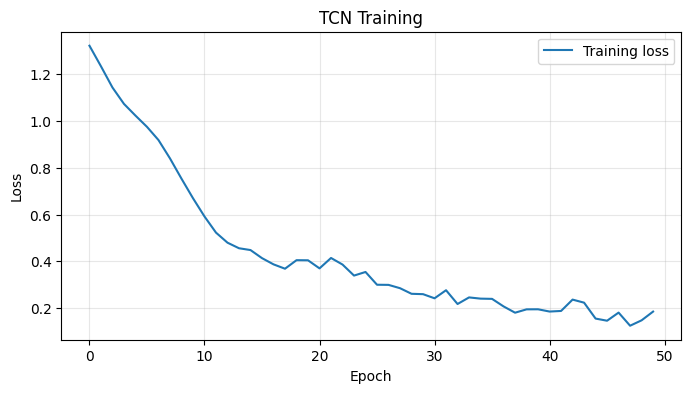

In [38]:
plt.figure(figsize=(8, 4))

plt.plot(
    loss_history,
    label="Training loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TCN Training")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


In [39]:
model.eval()

predictions = []
true_labels = []
all_probabilities = []

with torch.no_grad():

    for X_batch, y_batch in DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    ):

        X_batch = X_batch.to(device)

        output = model(X_batch)

        probs = torch.softmax(
            output,
            dim=1
        )

        pred = probs.argmax(
            dim=1
        )

        predictions.extend(
            pred.cpu().numpy()
        )

        true_labels.extend(
            y_batch.numpy()
        )

        all_probabilities.extend(
            probs.cpu().numpy()
        )


predictions = np.array(predictions)
true_labels = np.array(true_labels)
all_probabilities = np.array(
    all_probabilities
)


accuracy = accuracy_score(
    true_labels,
    predictions
)

print(
    f"TCN Test Accuracy: "
    f"{accuracy:.4f}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        true_labels,
        predictions,
        target_names=classes,
        zero_division=0
    )
)


TCN Test Accuracy: 0.9118

Classification Report:

              precision    recall  f1-score   support

   Fidgeting       1.00      0.89      0.94         9
    Gripping       1.00      0.75      0.86         8
        Idle       1.00      1.00      1.00         9
     Writing       0.73      1.00      0.84         8

    accuracy                           0.91        34
   macro avg       0.93      0.91      0.91        34
weighted avg       0.94      0.91      0.91        34



           Fidgeting  Gripping  Idle  Writing
Fidgeting          8         0     0        1
Gripping           0         6     0        2
Idle               0         0     9        0
Writing            0         0     0        8


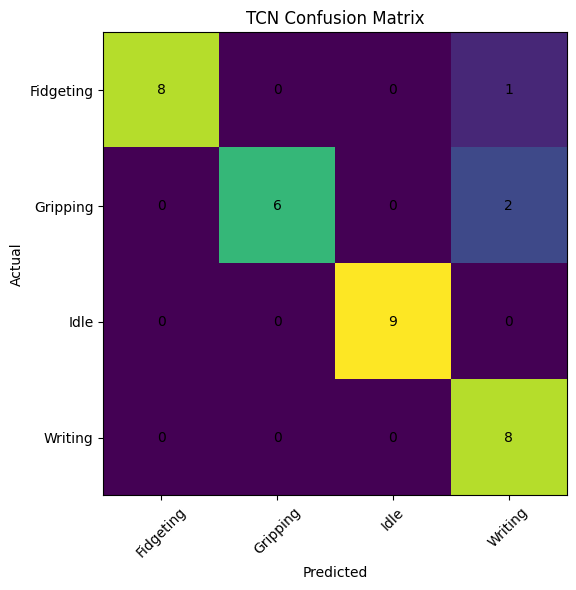

In [40]:
cm = confusion_matrix(
    true_labels,
    predictions
)

print(
    pd.DataFrame(
        cm,
        index=classes,
        columns=classes
    )
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TCN Confusion Matrix")

for i in range(len(classes)):
    for j in range(len(classes)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


In [41]:
def extract_rf_features(X):

    features = []

    for window in X:

        ax = window[:, 0]
        ay = window[:, 1]
        az = window[:, 2]

        gx = window[:, 3]
        gy = window[:, 4]
        gz = window[:, 5]

        acc_mag = np.sqrt(
            ax**2 +
            ay**2 +
            az**2
        )

        gyro_mag = np.sqrt(
            gx**2 +
            gy**2 +
            gz**2
        )

        jerk = np.diff(
            acc_mag
        )

        features.append([

            np.mean(acc_mag),

            np.var(acc_mag),

            np.sqrt(
                np.mean(jerk**2)
            ),

            np.sqrt(
                np.mean(gz**2)
            ),

            np.sqrt(
                np.mean(gyro_mag**2)
            )
        ])

    return np.array(features)


rf_train = extract_rf_features(
    train_X
)

rf_test = extract_rf_features(
    test_X
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED
)

rf.fit(
    rf_train,
    train_y_id
)

rf_predictions = rf.predict(
    rf_test
)

rf_accuracy = accuracy_score(
    test_y_id,
    rf_predictions
)

print(
    f"Random Forest Accuracy: "
    f"{rf_accuracy:.4f}"
)

print(
    classification_report(
        test_y_id,
        rf_predictions,
        target_names=classes,
        zero_division=0
    )
)


Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

   Fidgeting       1.00      1.00      1.00         9
    Gripping       1.00      1.00      1.00         8
        Idle       1.00      1.00      1.00         9
     Writing       1.00      1.00      1.00         8

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [42]:
comparison = pd.DataFrame({
    "Model": [
        "TCN",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        rf_accuracy
    ]
})

display(comparison)


,Model,Accuracy
0,TCN,0.911765
1,Random Forest,1.000000


In [43]:
test_stream = np.concatenate(
    test_stream_chunks,
    axis=0
)

test_stream_n = scaler.transform(
    test_stream
)

print(
    "Simulated stream:",
    len(test_stream_n),
    "samples"
)

print(
    "Duration:",
    f"{len(test_stream_n) / FS:.1f} seconds"
)


Simulated stream: 595 samples
Duration: 19.8 seconds


In [44]:
INFER_STRIDE = 3
CONFIDENCE_THRESHOLD = 0.60

def predict_stream(
    model,
    stream,
    window=WINDOW,
    stride=INFER_STRIDE
):

    model.eval()

    results = []

    with torch.no_grad():

        for t in range(
            window,
            len(stream),
            stride
        ):

            window_data = stream[
                t-window:t
            ]

            x = torch.tensor(
                window_data.T[None],
                dtype=torch.float32
            ).to(device)

            output = model(x)

            probs = torch.softmax(
                output,
                dim=1
            )

            confidence, pred = (
                probs.max(dim=1)
            )

            results.append({
                "sample": t,
                "label": classes[
                    pred.item()
                ],
                "confidence": confidence.item()
            })

    return pd.DataFrame(results)


stream_predictions = predict_stream(
    model,
    test_stream_n
)

display(
    stream_predictions.head(10)
)


,sample,label,confidence
0,30,Idle,0.969848
1,33,Idle,0.970237
2,36,Idle,0.969165
3,39,Idle,0.969714
4,42,Idle,0.970766
5,45,Idle,0.968745
6,48,Idle,0.969748
7,51,Idle,0.970055
8,54,Idle,0.968930
9,57,Idle,0.968759


In [45]:
PERSISTENCE_WINDOWS = 3
COOLDOWN_WINDOWS = 10

counter = 0
cooldown = 0

events = []

for _, row in stream_predictions.iterrows():

    label = row["label"]
    confidence = row["confidence"]

    if cooldown > 0:

        cooldown -= 1
        continue

    if confidence < CONFIDENCE_THRESHOLD:

        counter = 0
        continue

    if label in TRIGGER_CLASSES:

        counter += 1

    else:

        counter = 0


    if counter >= PERSISTENCE_WINDOWS:

        if label == "Idle":

            action = "ALERT"

        elif label == "Fidgeting":

            action = "GENTLE FEEDBACK"

        events.append({
            "sample": row["sample"],
            "time_s": row["sample"] / FS,
            "behaviour": label,
            "confidence": confidence,
            "action": action
        })

        counter = 0
        cooldown = COOLDOWN_WINDOWS


events = pd.DataFrame(events)

print("Feedback events:", len(events))

display(events)


Feedback events: 7


,sample,time_s,behaviour,confidence,action
0,36,1.2,Idle,0.969165,ALERT
1,75,2.5,Idle,0.966756,ALERT
2,114,3.8,Idle,0.968975,ALERT
3,153,5.1,Idle,0.967251,ALERT
4,192,6.4,Fidgeting,1.000000,GENTLE FEEDBACK
5,231,7.7,Fidgeting,1.000000,GENTLE FEEDBACK
6,270,9.0,Fidgeting,1.000000,GENTLE FEEDBACK


In [46]:
print("=" * 60)
print("             FOCUSPEN PROTOTYPE")
print("=" * 60)

for _, row in stream_predictions.iterrows():

    label = row["label"]
    confidence = row["confidence"]

    if confidence < CONFIDENCE_THRESHOLD:

        action = "IGNORE"

    elif label == "Idle":

        action = "ALERT"

    elif label == "Fidgeting":

        action = "GENTLE FEEDBACK"

    else:

        action = "NO FEEDBACK"

    print(
        f"{row['sample']/FS:6.1f}s | "
        f"{label:10s} | "
        f"{confidence:.2f} | "
        f"{action}"
    )


             FOCUSPEN PROTOTYPE
   1.0s | Idle       | 0.97 | ALERT
   1.1s | Idle       | 0.97 | ALERT
   1.2s | Idle       | 0.97 | ALERT
   1.3s | Idle       | 0.97 | ALERT
   1.4s | Idle       | 0.97 | ALERT
   1.5s | Idle       | 0.97 | ALERT
   1.6s | Idle       | 0.97 | ALERT
   1.7s | Idle       | 0.97 | ALERT
   1.8s | Idle       | 0.97 | ALERT
   1.9s | Idle       | 0.97 | ALERT
   2.0s | Idle       | 0.97 | ALERT
   2.1s | Idle       | 0.97 | ALERT
   2.2s | Idle       | 0.97 | ALERT
   2.3s | Idle       | 0.97 | ALERT
   2.4s | Idle       | 0.97 | ALERT
   2.5s | Idle       | 0.97 | ALERT
   2.6s | Idle       | 0.97 | ALERT
   2.7s | Idle       | 0.97 | ALERT
   2.8s | Idle       | 0.97 | ALERT
   2.9s | Idle       | 0.97 | ALERT
   3.0s | Idle       | 0.97 | ALERT
   3.1s | Idle       | 0.97 | ALERT
   3.2s | Idle       | 0.97 | ALERT
   3.3s | Idle       | 0.97 | ALERT
   3.4s | Idle       | 0.97 | ALERT
   3.5s | Idle       | 0.97 | ALERT
   3.6s | Idle       | 0.97 | AL

In [47]:
!pip install onnxscript
import torch
import torch.nn as nn
import onnx

# 1. Define your class
class TCNWithNormalization(nn.Module):
    def __init__(self, trained_model, mean, scale):
        super().__init__()
        self.model = trained_model
        self.register_buffer(
            "mean", torch.tensor(mean, dtype=torch.float32).view(1, -1, 1)
        )
        self.register_buffer(
            "scale", torch.tensor(scale, dtype=torch.float32).view(1, -1, 1)
        )

    def forward(self, x):
        x = (x - self.mean) / self.scale
        return self.model(x)

# --- REPLACE THIS PART ---
# Move the inner model to CPU before wrapping it
model.cpu().eval()

# Create the wrapper, and explicitly move it to CPU as well
export_model = TCNWithNormalization(
    model, scaler.mean_, scaler.scale_
).cpu().eval()
# -------------------------

NUM_CHANNELS = len(FEATURES)  
SEQ_LEN = WINDOW              
ONNX_OUT_PATH = "focuspen_tcn.onnx"

# The dummy input defaults to CPU, which now matches the model
dummy_input = torch.randn(1, NUM_CHANNELS, SEQ_LEN)

# Proceed with export
torch.onnx.export(
    export_model,
    dummy_input,
    ONNX_OUT_PATH,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch", 2: "seq_len"},
        "logits": {0: "batch"},
    },
    opset_version=13,
    dynamo=False,
)

# Safeguard
_onnx_model = onnx.load(ONNX_OUT_PATH, load_external_data=True)
onnx.save_model(_onnx_model, ONNX_OUT_PATH, save_as_external_data=False)

print(f"Exported to {ONNX_OUT_PATH}")
print(f"Input : 'input'  shape [batch, {NUM_CHANNELS}, seq_len]  channels = ax, ay, az, gx, gy, gz (raw, un-normalized)")
print(f"Output: 'logits' shape [batch, {len(classes)}]  classes (in order) = {classes}")
print()
print(f"On the website: set Sequence length = {SEQ_LEN}, Input tensor name = input")
print(f"IMPORTANT: the website's CLASS_ORDER array must read {classes} to match this model's output order.")


Exported to focuspen_tcn.onnx
Input : 'input'  shape [batch, 6, seq_len]  channels = ax, ay, az, gx, gy, gz (raw, un-normalized)
Output: 'logits' shape [batch, 4]  classes (in order) = [np.str_('Fidgeting'), np.str_('Gripping'), np.str_('Idle'), np.str_('Writing')]

On the website: set Sequence length = 30, Input tensor name = input
IMPORTANT: the website's CLASS_ORDER array must read [np.str_('Fidgeting'), np.str_('Gripping'), np.str_('Idle'), np.str_('Writing')] to match this model's output order.


/tmp/ipykernel_59/2043345375.py:40: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [48]:
# Kaggle: this makes a clickable download link right in the notebook output.
# (You can also grab the file from the "Output" panel on the right after running all cells.)
from IPython.display import FileLink
FileLink(ONNX_OUT_PATH)


/kaggle/working/focuspen_tcn.onnx